In [6]:
#jupyter nbconvert --to pdf --no-input CCF_Report.ipynb 

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
import plotly.graph_objects as go
from prettytable import PrettyTable
from ImportCCF import import_ccf

import_ccf()

In [7]:
# interpolate the CCF to match the Paros times
CCF = pd.read_csv(r'G:\My Drive\Projects\CCFBubbler\TestData\CapeVincent\csv\CCF.csv')
Paros = pd.read_csv(r'G:\My Drive\Projects\CCFBubbler\TestData\CapeVincent\csv\Paros.csv')
CCF['datetime'] = pd.to_datetime(CCF['datetime'])
Paros['datetime'] = pd.to_datetime(Paros['datetime'])
CCF.set_index('datetime', inplace=True)
Paros.set_index('datetime', inplace=True)
#print(Paros.index[0])

In [8]:
#reindex onto a full time series
Paros.index = Paros.index.map(lambda t: t.replace(second=30)) # it changes to 35 seconds for some reason, so I'm just changing those to 30
Paros = Paros[~Paros.index.duplicated(keep='first')]
start_time = pd.to_datetime('2024-12-22 00:01:30')
end_time = Paros.index.max()
uniform_time = pd.date_range(start=start_time, end=end_time, freq='6min')
Paros_newtime = Paros.reindex(uniform_time)

In [9]:
BWL1 = CCF['BWL1'].values
BWL2 = CCF['BWL2'].values
ccf_time = CCF.index

BWL1_interp = np.interp(uniform_time.astype(np.int64),
                        ccf_time.astype(np.int64),
                        BWL1)
BWL1_interp = np.round(BWL1_interp, 3) # they're originally truncated at 3 decimals, so I made these as well
BWL2_interp = np.interp(uniform_time.astype(np.int64),
                        ccf_time.astype(np.int64),
                        BWL2)
BWL2_interp = np.round(BWL2_interp, 3)
ccf_interp = pd.DataFrame({'datetime': uniform_time,
                           'BWL1': BWL1_interp,
                           'BWL2': BWL2_interp}, index=uniform_time)

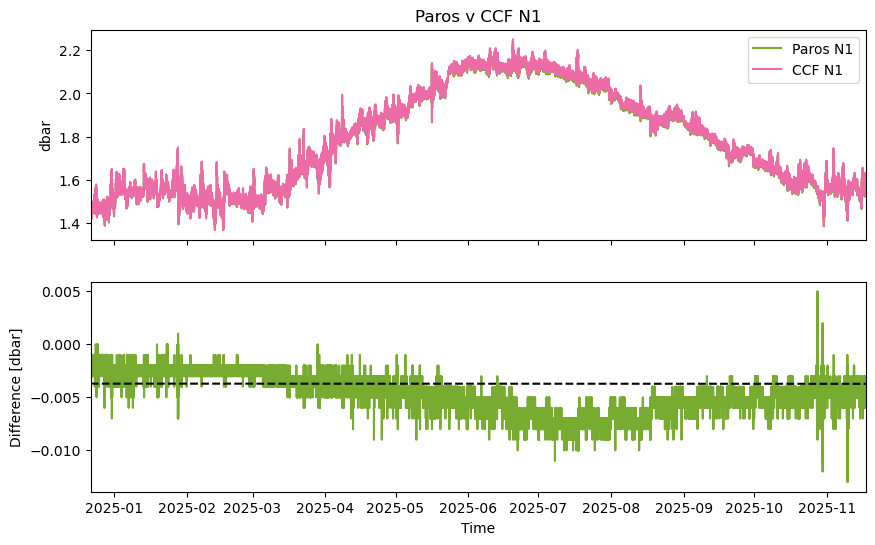

In [10]:
# compare N1s
diff_N1 = np.array(Paros_newtime['BN1'] - ccf_interp['BWL1'])

# Plot
plt.rcParams['axes.prop_cycle'] = plt.cycler(color=[(0.4660, 0.6740 ,0.1880), (0.9300,    0.4200,    0.6500), (0.1, 0.1, 0.5)])
fig1, ax1 = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

# First plot: Both time series
ax1[0].plot(Paros_newtime.index, Paros_newtime['BN1'], label='Paros N1')
ax1[0].plot(ccf_interp.index, ccf_interp['BWL1'], label='CCF N1')
ax1[0].set_ylabel('dbar')
ax1[0].legend()
ax1[0].set_title('Paros v CCF N1')
ax1[0].set_xlim(Paros_newtime.index.min(), Paros_newtime.index.max())

ax1[1].plot(Paros_newtime.index, diff_N1)
ax1[1].set_ylabel('Difference [dbar]')
ax1[1].set_xlabel('Time')

mask = np.isfinite(diff_N1)
diff_N1_nonans = diff_N1[mask]
x_values = np.arange(len(diff_N1_nonans))
y_values = diff_N1_nonans

slope_N1, intercept_N1 = np.polyfit(x_values, y_values, 1)
ax1[1].plot(x_values, slope_N1 * x_values + intercept_N1, color='black', linestyle='--')
plt.show()

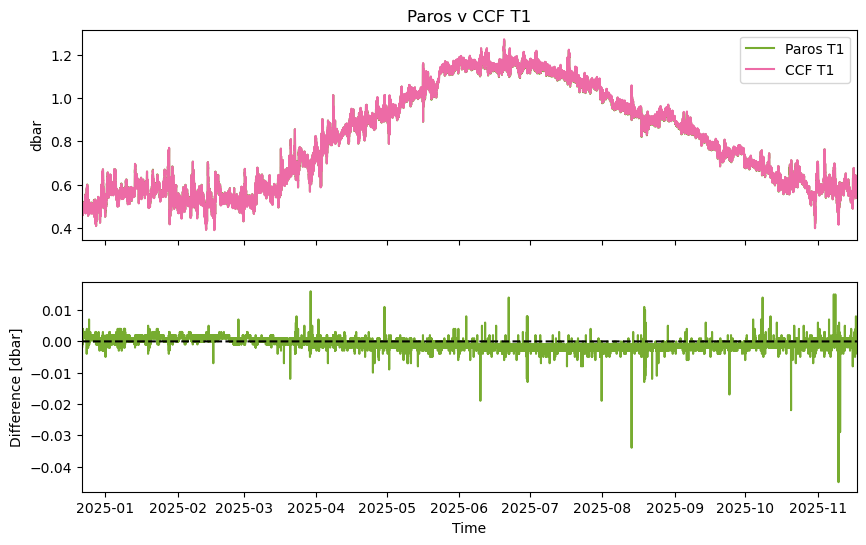

In [11]:
#Compare T1s
diff_T1 = np.array(Paros_newtime['BT1'] - ccf_interp['BWL2'])

# Plot
plt.rcParams['axes.prop_cycle'] = plt.cycler(color=[(0.4660, 0.6740 ,0.1880), (0.9300,    0.4200,    0.6500), (0.1, 0.1, 0.5)])
fig2, ax2 = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

# First plot: Both time series
ax2[0].plot(Paros_newtime.index, Paros_newtime['BT1'], label='Paros T1')
ax2[0].plot(ccf_interp.index, ccf_interp['BWL2'], label='CCF T1')
ax2[0].set_ylabel('dbar')
ax2[0].legend()
ax2[0].set_title('Paros v CCF T1')
ax2[0].set_xlim(Paros_newtime.index.min(), Paros_newtime.index.max())

ax2[1].plot(Paros_newtime.index, diff_T1)
ax2[1].set_ylabel('Difference [dbar]')
ax2[1].set_xlabel('Time')

mask = np.isfinite(diff_T1)
diff_T1_nonans = diff_T1[mask]
x_values = np.arange(len(diff_T1_nonans))
y_values = diff_T1_nonans
slope_T1, intercept_T1 = np.polyfit(x_values, y_values, 1)
ax2[1].plot(x_values, slope_T1 * x_values + intercept_T1, color='black', linestyle='--')
plt.show()

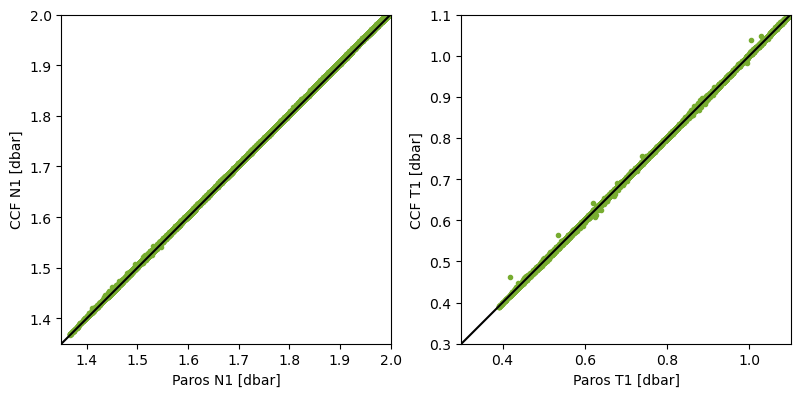

In [12]:
fig3, (ax3, ax4) = plt.subplots(1, 2, figsize=(8, 8), constrained_layout=True)

ax3.plot(Paros_newtime['BN1'], ccf_interp['BWL1'], '.')
ax3.plot([1.35, 2], [1.35, 2], 'k')
ax3.set_xlabel('Paros N1 [dbar]')
ax3.set_ylabel('CCF N1 [dbar]')
ax3.set_aspect('equal', adjustable='box')
ax3.set_xlim(1.35, 2)
ax3.set_ylim(1.35, 2)

ax4.plot(Paros_newtime['BT1'], ccf_interp['BWL2'], '.')
ax4.plot([0.3, 1.1], [0.3, 1.1], 'k')
ax4.set_xlabel('Paros T1 [dbar]')
ax4.set_ylabel('CCF T1 [dbar]')
ax4.set_aspect('equal', adjustable='box')
ax4.set_xlim(0.3, 1.1)
ax4.set_ylim(0.3, 1.1)
plt.show()


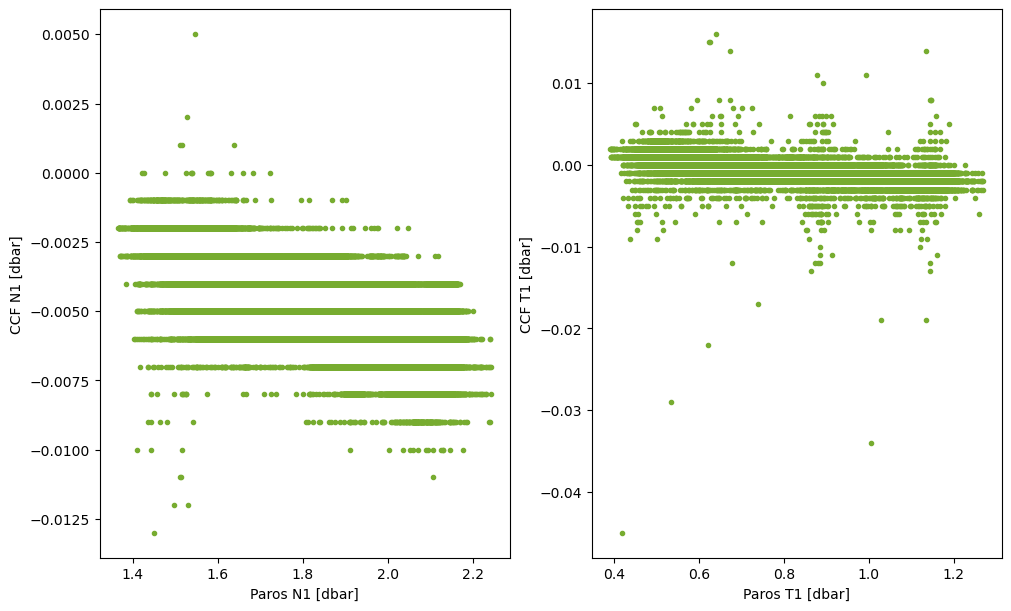

In [13]:
fig6, (ax6a, ax6b) = plt.subplots(1, 2, figsize=(10, 6), constrained_layout=True)
ax6a.plot(Paros_newtime['BN1'], diff_N1, '.')
#ax6a.plot([1.35, 2], [1.35, 2], 'k')
ax6a.set_xlabel('Paros N1 [dbar]')
ax6a.set_ylabel('CCF N1 [dbar]')
#ax6a.set_aspect('equal', adjustable='box')
#ax6a.set_xlim(1.35, 2)
#ax6a.set_ylim(1.35, 2)

ax6b.plot(Paros_newtime['BT1'], diff_T1, '.')
#ax6b.plot([0.3, 1.1], [0.3, 1.1], 'k')
ax6b.set_xlabel('Paros T1 [dbar]')
ax6b.set_ylabel('CCF T1 [dbar]')
#ax6b.set_aspect('equal', adjustable='box')
#ax6b.set_xlim(0.3, 1.1)
#ax6b.set_ylim(0.3, 1.1)
plt.show()


\pagebreak

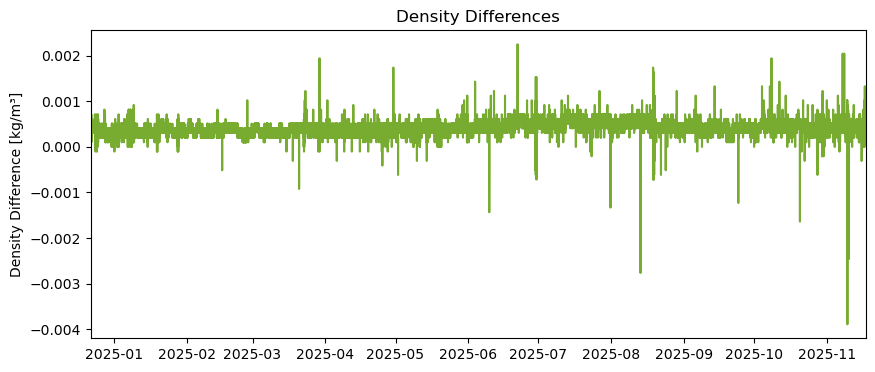

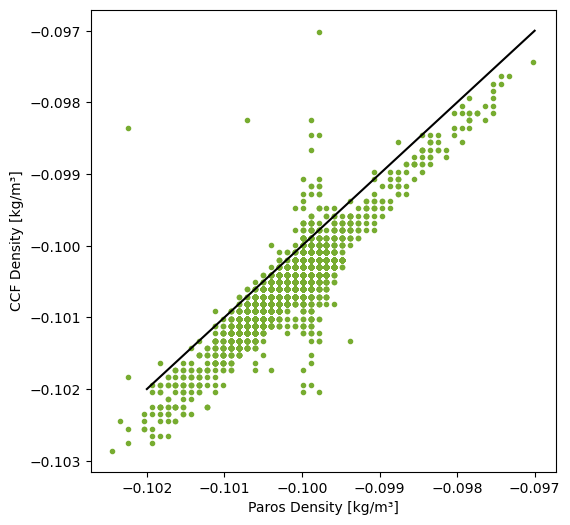

In [14]:
# Find instantaneous density
# offset between two orifice is 0.996m
rho_paros  = (Paros_newtime['BT1'] - Paros_newtime['BN1'])/9.8/0.996
rho_ccf = (ccf_interp['BWL2'] - ccf_interp['BWL1'])/9.8/0.996
diff_rho = rho_paros-rho_ccf

fig4 = plt.figure(figsize=(10,4))
plt.plot(diff_rho)
ax = plt.gca()  # get current axes
ax.set_xlim(Paros_newtime.index.min(), Paros_newtime.index.max())
plt.ylabel('Density Difference [kg/m\u00B3]')
plt.title('Density Differences')
plt.show()

fig5 = plt.figure(figsize=(6, 6))
plt.plot(rho_paros, rho_ccf, '.')
plt.plot([-.102, -.097], [-.102, -.097], 'k')
plt.xlabel('Paros Density [kg/m\u00B3]')
plt.ylabel('CCF Density [kg/m\u00B3]')
ax3.set_aspect('equal', adjustable='box')
plt.show()

In [15]:
# Table of Results
table_N1 = PrettyTable(["Period", "Avg Diff [mbar]", "Std Dev [mbar]", "RMS [mbar]", "Trend [mbar/d]"])
table_N1.title ="N1"
table_N1.add_row(["All Time", f"{np.mean(diff_N1_nonans)*100:.3f}", f"{np.std(diff_N1_nonans)*100:.3f}", f"{np.sqrt(np.mean(diff_N1_nonans**2))*100:.3f}", f"{slope_N1*100/(60*60*24):.3f}"])
print(table_N1)

table_T1 = PrettyTable(["Period", "Avg Diff [mbar]", "Std Dev [mbar]", "RMS [mbar]", "Trend [mbar/d]"])
table_T1.title ="T1"
table_T1.add_row(["All Time", f"{np.mean(diff_T1_nonans)*100:.3f}", f"{np.std(diff_T1_nonans)*100:.3f}", f"{np.sqrt(np.mean(diff_T1_nonans**2))*100:.3f}", f"{slope_T1*100/(60*60*24):.3f}"])
print(table_T1)

table_rho = PrettyTable(["Period", "Avg Diff [kg/m\u00B3]", "Std Dev [kg/m\u00B3]", "RMS [kg/m\u00B3]", "Trend [kg/m\u00B3/d]"])
table_rho.title ="Density"
table_rho.add_row(["All Time", f"{np.mean(diff_rho)*100:.3f}", f"{np.std(diff_rho)*100:.3f}", f"{np.sqrt(np.mean(diff_rho**2))*100:.3f}", f"{slope_T1*100/(60*60*24):.3f}"])
print(table_rho)



+---------------------------------------------------------------------------+
|                                     N1                                    |
+----------+-----------------+----------------+------------+----------------+
|  Period  | Avg Diff [mbar] | Std Dev [mbar] | RMS [mbar] | Trend [mbar/d] |
+----------+-----------------+----------------+------------+----------------+
| All Time |      -0.464     |     0.172      |   0.495    |     -0.000     |
+----------+-----------------+----------------+------------+----------------+
+---------------------------------------------------------------------------+
|                                     T1                                    |
+----------+-----------------+----------------+------------+----------------+
|  Period  | Avg Diff [mbar] | Std Dev [mbar] | RMS [mbar] | Trend [mbar/d] |
+----------+-----------------+----------------+------------+----------------+
| All Time |      -0.064     |     0.131      |   0.146    |    

In [16]:
#jupyter nbconvert --to pdf --no-input CCF_Report.ipynb 

In [17]:
import shutil

src = r"G:\My Drive\Projects\CCFBubbler\CCF_Report.pdf"
dst = r"G:\Shared drives\NOS CO-OPS OSTEP\WEBSITE (NEW)\Documents\Bubbler\CCF_Report.pdf"

shutil.copy(src, dst)  

'G:\\Shared drives\\NOS CO-OPS OSTEP\\WEBSITE (NEW)\\Documents\\Bubbler\\CCF_Report.pdf'